#📌 Extracción

In [168]:
#Se importan las bibliotecas iniciales  necesarias para el desafio
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker


In [112]:
ruta_archivo='https://raw.githubusercontent.com/VillaltaE/netflix_churn/refs/heads/main/netflix_customer_churn.csv'
df = pd.read_csv(ruta_archivo)


In [113]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [114]:
df.sample(5)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
3935,50ebca29-2130-4894-9f3c-63f3f938f819,59,Other,Basic,8.48,24,North America,TV,8.99,1,Crypto,1,0.34,Drama
2543,2f4b3f98-c2e9-49e2-bc44-5bfd637d4dec,30,Female,Basic,2.56,32,Oceania,Tablet,8.99,1,Crypto,1,0.08,Horror
1257,b9be612d-c7cc-411f-afac-093196f87239,22,Male,Premium,21.47,51,South America,TV,17.99,0,PayPal,3,0.41,Sci-Fi
150,ebfb8aef-3cb5-40e2-9eed-15a73a544d43,30,Male,Premium,7.24,40,Asia,TV,17.99,0,Debit Card,5,0.18,Documentary
1666,1afd1afc-9a16-4a59-9391-b5165327d402,69,Male,Basic,21.53,7,North America,Laptop,8.99,0,Crypto,3,2.69,Comedy


#🔧 Transformación

#📊 Carga y análisis

In [115]:
#Informacion general del data frame, para conocer los tipo de datos y cuantos son nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [116]:
# Copmprobando si hay los valores nulos
print(df.isnull().sum())

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64


In [117]:
Columns = df.columns
print(Columns)

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')


In [118]:
#Numero de columnas
df.shape[1]

14

In [119]:
#Numero de filas
df.shape[0]

5000

In [120]:
#Se elimina 'customer_id' no se usará en el análisis
df = df.drop(['customer_id'],axis=1)
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [121]:
# Relación churn = 1 respecto chrun = 0
df['churned'].value_counts(normalize=True)

,proportion
churned,
1,0.503
0,0.497


In [122]:
#Numero de churn =  1
df['churned'].value_counts()


,count
churned,
1,2515
0,2485


In [123]:
# Analisis de los usuarios que se salieron
df_si_churned = df[df['churned'] == 1].copy()

In [124]:
# Analisis de los usuarios que se salieron
df_si_churned.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,2515.000000,2515.000000,2515.000000,2515.000000,2515.0,2515.000000,2515.000000
mean,43.793241,5.918497,38.309344,13.125189,1.0,2.801193,0.164048
std,15.472773,5.418978,14.751904,3.764869,0.0,1.383301,0.186164
min,18.000000,0.010000,0.000000,8.990000,1.0,1.000000,0.000000
25%,30.000000,1.830000,30.000000,8.990000,1.0,2.000000,0.060000
50%,44.000000,4.060000,41.000000,13.990000,1.0,3.000000,0.120000
75%,57.000000,8.710000,50.000000,17.990000,1.0,4.000000,0.230000
max,70.000000,41.330000,60.000000,17.990000,1.0,5.000000,4.320000


In [125]:
# Analisis de los usuarios que no se salieron
df_no_churned = df[df['churned'] == 0].copy()

In [126]:
# Analisis de los usuarios que no se salieron
df_no_churned.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,2485.000000,2485.000000,2485.000000,2485.000000,2485.0,2485.000000,2485.000000
mean,43.902213,17.449590,21.771026,14.248350,0.0,3.250302,1.594133
std,15.532694,13.923952,16.155030,3.528817,0.0,1.412834,3.570493
min,18.000000,0.010000,0.000000,8.990000,0.0,1.000000,0.000000
25%,30.000000,7.380000,9.000000,8.990000,0.0,2.000000,0.400000
50%,44.000000,13.860000,19.000000,13.990000,0.0,3.000000,0.720000
75%,58.000000,24.020000,30.000000,17.990000,0.0,4.000000,1.460000
max,70.000000,110.400000,60.000000,17.990000,0.0,5.000000,98.420000


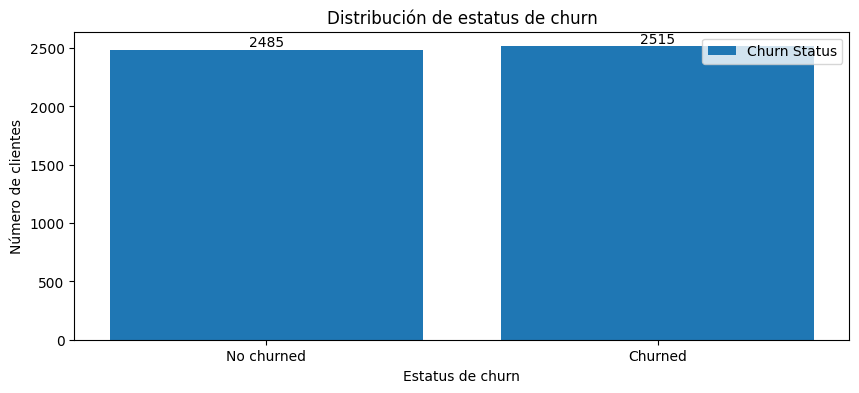

In [127]:
#Graficar el estatus de los evasores vs no evasores
no_churn = df[df['churned'] == 0]
yes_churn = df[df['churned'] == 1]

# Obtenga el recuento total de los clientes evasores y no evasores
no_churn_count = len(df[df['churned'] == 0])
yes_churn_count = len(df[df['churned'] == 1])
fig,ax = plt.subplots(1,1,figsize=(10,4))

#Crea una lista de etiquetas y recuentos correspondientes para las barras.
labels = ['No churned', 'Churned']
counts = [no_churn_count, yes_churn_count]

#Crea el gráfico de barras. El primer argumento es la posición x o las etiquetas,
# y el segundo es la altura de las barras.
bars = ax.bar(labels, counts, label='Churn Status')

# Incluye leyenda
ax.legend()

# agregue títulos y etiquetas para mayor claridad.
ax.set_title('Distribución de estatus de churn')
ax.set_xlabel('Estatus de churn')
ax.set_ylabel('Número de clientes')

# Agregar los números de clientes en las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

plt.show()

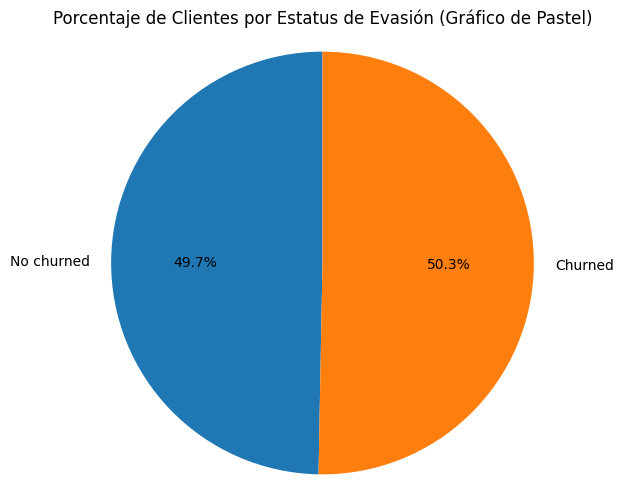

In [128]:

# Calcula el número total de clientes
total_customers = len(df)


# Calcula los porcentajes
percentages = [count / total_customers * 100 for count in counts]

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Porcentaje de Clientes por Estatus de Evasión (Gráfico de Pastel)')
ax.axis('equal')  # Aspecto igual asegura que el pastel se dibuja como un círculo.
plt.show()

In [129]:
#Datos de gender de los que se fueron
#no_churn.groupby('InternetService')['InternetService'].count()
yes_churn.groupby('gender')['gender'].count()  # se van mas mujeres respecto a los otros generos

,gender
gender,
Female,874
Male,827
Other,814


In [130]:
#Datos de gender de los que se no se fueron

no_churn.groupby('gender')['gender'].count() # se van mas mujeres respecto a los otros generos

,gender
gender,
Female,837
Male,827
Other,821


In [131]:
#Agrupando por tipo de subscripcion de los que se van
yes_churn.groupby('subscription_type')['subscription_type'].count()

,subscription_type
subscription_type,
Basic,1027
Premium,740
Standard,748


In [132]:
#Agrupando por tipo de subscripcion de los que no se van
no_churn.groupby('subscription_type')['subscription_type'].count()

,subscription_type
subscription_type,
Basic,634
Premium,953
Standard,898


In [133]:
#Agrupando por tipo de region de los que se van
yes_churn.groupby('region')['region'].count()

,region
region,
Africa,388
Asia,426
Europe,448
North America,421
Oceania,383
South America,449


In [134]:
#Agrupando por tipo de region de los que no se van
no_churn.groupby('region')['region'].count()

,region
region,
Africa,415
Asia,415
Europe,419
North America,430
Oceania,382
South America,424


In [135]:
#Agrupando por tipo de device(equipo) de los que se van
yes_churn.groupby('device')['device'].count()

,device
device,
Desktop,467
Laptop,521
Mobile,507
TV,496
Tablet,524


In [136]:
#Agrupando por tipo de device(equipo) de los que no se van
no_churn.groupby('device')['device'].count()

,device
device,
Desktop,482
Laptop,485
Mobile,497
TV,497
Tablet,524


In [137]:
#Agrupando por motodo de pago de los que se van
yes_churn.groupby('payment_method')['payment_method'].count()

,payment_method
payment_method,
Credit Card,424
Crypto,594
Debit Card,450
Gift Card,564
PayPal,483


In [138]:
#Agrupando por motodo de pago de los que no se van
no_churn.groupby('payment_method')['payment_method'].count()

,payment_method
payment_method,
Credit Card,549
Crypto,401
Debit Card,580
Gift Card,412
PayPal,543


In [139]:
#Agrupando porgenero favorito  de los que se van
yes_churn.groupby('favorite_genre')['favorite_genre'].count()

,favorite_genre
favorite_genre,
Action,365
Comedy,342
Documentary,370
Drama,382
Horror,367
Romance,350
Sci-Fi,339


In [140]:
#Agrupando porgenero favorito  de los que no se van
no_churn.groupby('favorite_genre')['favorite_genre'].count()

,favorite_genre
favorite_genre,
Action,332
Comedy,343
Documentary,359
Drama,349
Horror,346
Romance,375
Sci-Fi,381


In [141]:
#Media de horas vistas de los que se van
yes_churn['watch_hours'].mean()

np.float64(5.918497017892644)

In [142]:
#Media de horas vistas de los que no se van
no_churn['watch_hours'].mean()

np.float64(17.449589537223343)

In [143]:
#Media de los dias desde la ultima conexión  de los que se van
yes_churn['last_login_days'].mean()

np.float64(38.30934393638171)

In [144]:
#Media de los dias desde la ultima conexión  de los no que se van
no_churn['last_login_days'].mean()

np.float64(21.77102615694165)

In [145]:
#Media del pago mensual de los que se van
yes_churn['monthly_fee'].mean()

np.float64(13.125188866799201)

In [146]:
#Media del pago mensual de los que no se van
no_churn['monthly_fee'].mean()

np.float64(14.24835010060362)

In [147]:
#Media del número de perfiles de los que se van
yes_churn['number_of_profiles'].mean()

np.float64(2.801192842942346)

In [148]:
#Media del número de perfiles de los que no se van
no_churn['number_of_profiles'].mean()

np.float64(3.2503018108651913)

In [149]:
#Media del promedio de tiempo viendo Netflix por dia  de los que se van
yes_churn['avg_watch_time_per_day'].mean()

np.float64(0.16404771371769386)

In [150]:
#Media del promedio de tiempo viendo Netflix por dia  de los que no se van
no_churn['avg_watch_time_per_day'].mean()

np.float64(1.5941327967806842)

In [151]:
df.columns

Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'churned', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre'],
      dtype='object')

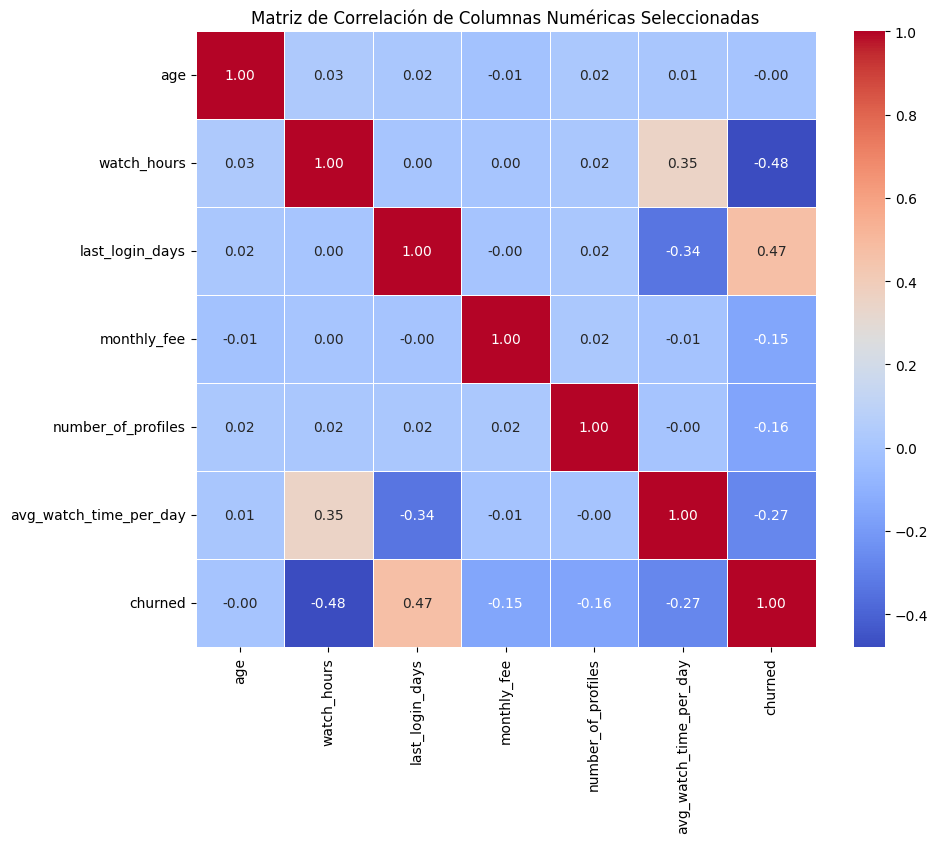

In [152]:
# Crear una matriz de correlación para columnas numéricas seleccionadas
# Seleccionar algunas columnas numéricas para incluir en la matriz de correlación
numeric_cols = ['age','watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day','churned']

# Calcular la matriz de correlación
correlation_matrix = df[numeric_cols].corr()

# Crear un mapa de calor (heatmap) para la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Columnas Numéricas Seleccionadas')
plt.show()

### **Análisis exploratorio de las variables categóricas**

#### Análisis de la variable churn

In [153]:
conteo_churn = df['churned'].value_counts(normalize=True)

In [154]:
proporcion_churn = df['churned'].value_counts(normalize=True)

In [155]:
conteo_churn

,proportion
churned,
1,0.503
0,0.497


In [156]:
proporcion_churn

,proportion
churned,
1,0.503
0,0.497


##### Distribución de la variable churn

In [157]:
#Establecer los colores para las categorías de churn
colores = ['#37513D','#FA1B22']

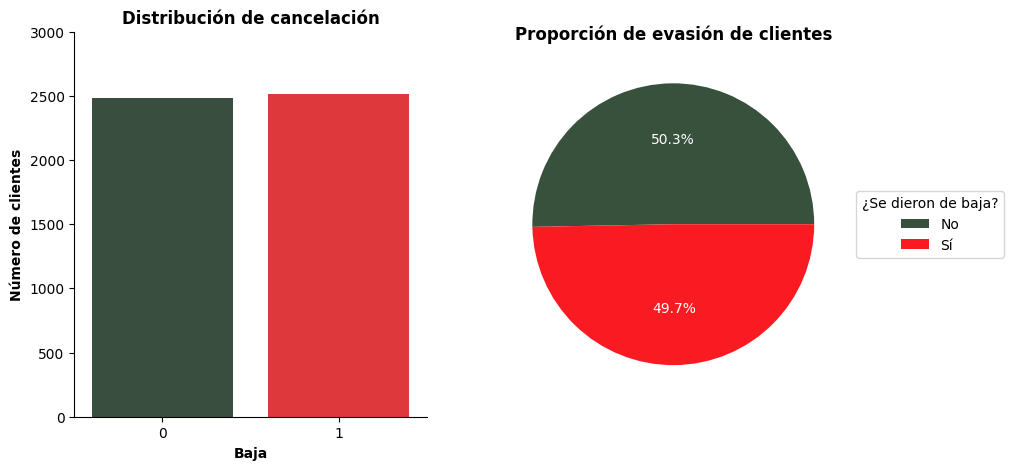

In [158]:
#Definir las etiquetas del eje x
etiquetas_baja = ['No', 'Sí']

fig, axs = plt.subplots(1, 2, figsize=(10,5))

#Gráfico de barras de la variable churn
sns.countplot(ax=axs[0], data=df,
              x=df['churned'],
              hue=df['churned'],
              palette=colores,
              legend=False)

axs[0].set_title('Distribución de cancelación', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Baja', fontsize=10, fontweight='bold')
axs[0].set_ylabel('Número de clientes', fontsize=10, fontweight='bold')
axs[0].set_ylim(0, 3000)
axs[0].spines[['top', 'right']].set_visible(False)

#Gráfico de torta de la variable churn
axs[1].pie(proporcion_churn,
           labels=etiquetas_baja,
           colors=colores,
           autopct='%1.1f%%',
           textprops=dict(color="w"))

axs[1].set_title('Proporción de evasión de clientes', loc='center', fontsize=12, fontweight='bold')
axs[1].legend(title="¿Se dieron de baja?", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()

#### Análisis explotatorio de las variables :
- Sexo.
- Subscripción.
- Región.
- Dispositivos.
- Método de pago.
- Género favorito.

In [159]:
#Lista con las variables categoricas sin churn
columnas_categoricas = list(df.select_dtypes('object'))
columnas_categoricas


['gender',
 'subscription_type',
 'region',
 'device',
 'payment_method',
 'favorite_genre']

In [160]:
columnas_categoricas

['gender',
 'subscription_type',
 'region',
 'device',
 'payment_method',
 'favorite_genre']

In [161]:
##### Tabla con la estadística descriptiva de las variables categóricas
tabla_categoricas = df[columnas_categoricas].describe()


In [162]:
tabla_categoricas

,gender,subscription_type,region,device,payment_method,favorite_genre
count,5000,5000,5000,5000,5000,5000
unique,3,3,6,5,5,7
top,Female,Premium,South America,Tablet,Debit Card,Drama
freq,1711,1693,873,1048,1030,731


In [163]:
#Calculo de tasa promedio global
baja_promedio_global = df['churned'].mean()

In [164]:
def tabla_categorica(df, col1, col2, normalize=False):
  """
  Función que retorna una tabla de contingencia entre las variables seleccionadas
  """
  tabla = pd.crosstab(df[col1], df[col2], normalize=normalize)
  tabla.reset_index(inplace=True)
  tabla.columns.name = ''
  return tabla

In [165]:

def graficos_categoricas(tabla1, tabla2, columna1, columna2='baja'):
  """
  Función que genera los gráficos de barras para las dos tablas de contingencia
  obtenidas para evaluar la relación entre las variables categóricas y objetivo
  """
  # --PREPARANDO LOS DATOS DE LA TABLA 1
  tabla_recuento = tabla1.melt(id_vars=columna1, var_name=columna2, value_name='conteo')

  fig, axs = plt.subplots(1, 2, figsize=(14, 7))

  # --- GRÁFICO 1: RECUENTO ---
  sns.barplot(ax=axs[0],
              data=tabla_recuento,
              x=columna1,
              y='conteo',
              hue=columna2,
              palette=colores)

  axs[0].set_title(f'Distribución de {columna2} por {columna1.capitalize()}', fontsize=12, fontweight='bold')
  axs[0].set_xlabel(columna1.capitalize(), fontweight='bold')
  axs[0].set_ylabel('Número de clientes', fontweight='bold')
  axs[0].set_ylim(0, tabla_recuento['conteo'].max() * 1.15)
  axs[0].yaxis.set_minor_locator(ticker.AutoMinorLocator())
  axs[0].spines[['top', 'right']].set_visible(False)

  # Obtenemos los 'handles' (los cuadraditos de colores) que Seaborn ya creó
  handles, _ = axs[0].get_legend_handles_labels()

  #Dibujamos la leyenda usando esos mismos colores pero nuevas etiquetas
  axs[0].legend(handles=handles, labels=['No', 'Si'], title='¿Abandonó?', ncols=2)

  # --- GRÁFICO 2: TASA ---
  # Graficamos la columna '1' que representa la tasa de abandono
  sns.barplot(ax=axs[1], data=tabla2, x=columna1, y=1, hue=columna1, palette='rocket')
  axs[1].set_title(f'Tasa de evasión por {columna1.capitalize()}', fontsize=12, fontweight='bold')
  axs[1].set_xlabel(columna1.capitalize(), fontweight='bold')
  axs[1].set_ylabel('Tasa de abandono (0 a 1)', fontweight='bold')
  axs[1].set_ylim(0, 1)
  axs[1].yaxis.set_minor_locator(ticker.AutoMinorLocator())
  axs[1].spines[['top', 'right']].set_visible(False)

  # Añadimos una línea punteada con la tasa promedio de evasión global para referencia
  tasa_promedio = tabla2[1].mean()
  axs[1].axhline(baja_promedio_global, color='red', linestyle='--', alpha=0.6, label=f'Promedio ({tasa_promedio:.2f})')
  axs[1].legend()

  plt.tight_layout()
  plt.show()


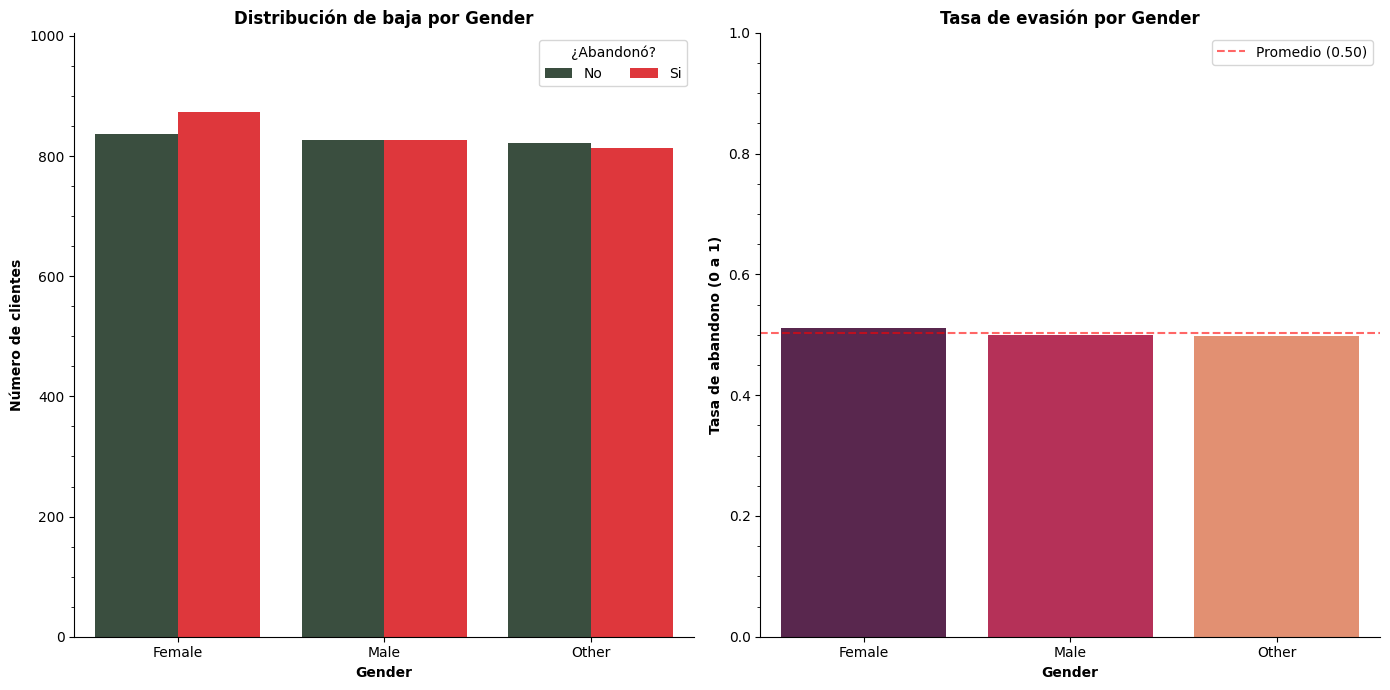

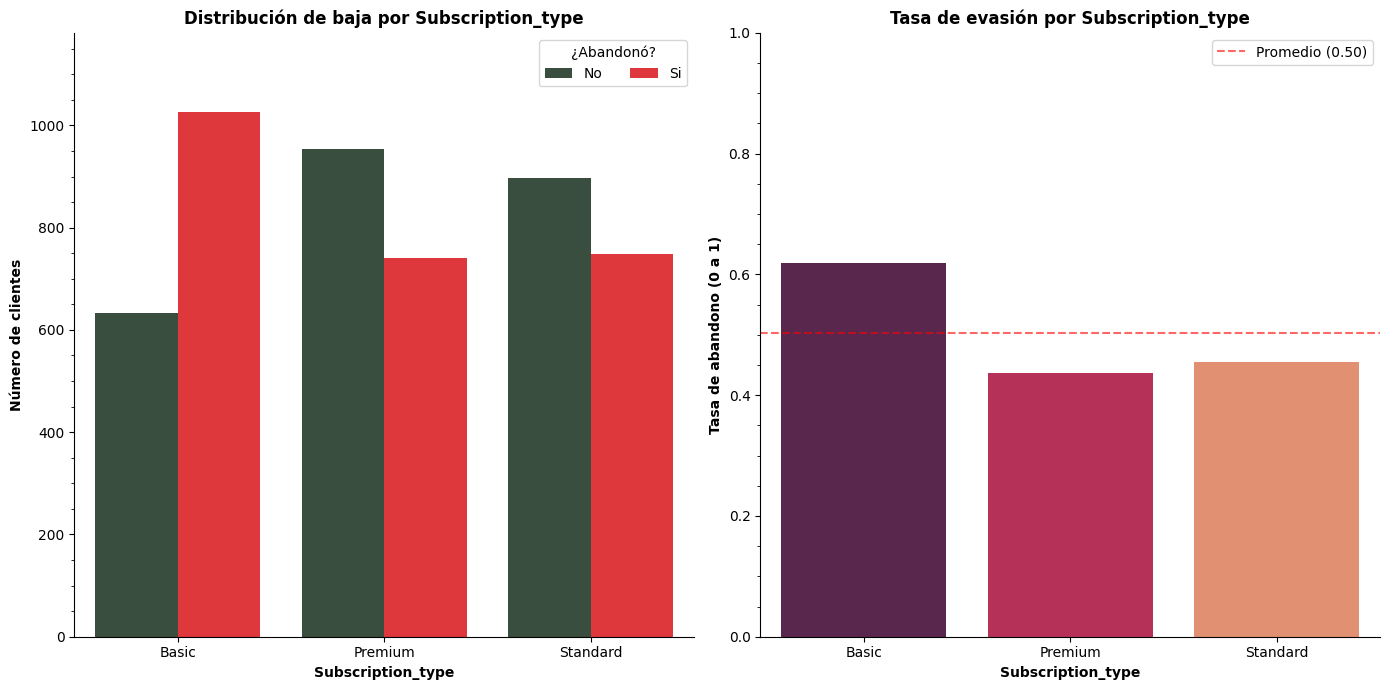

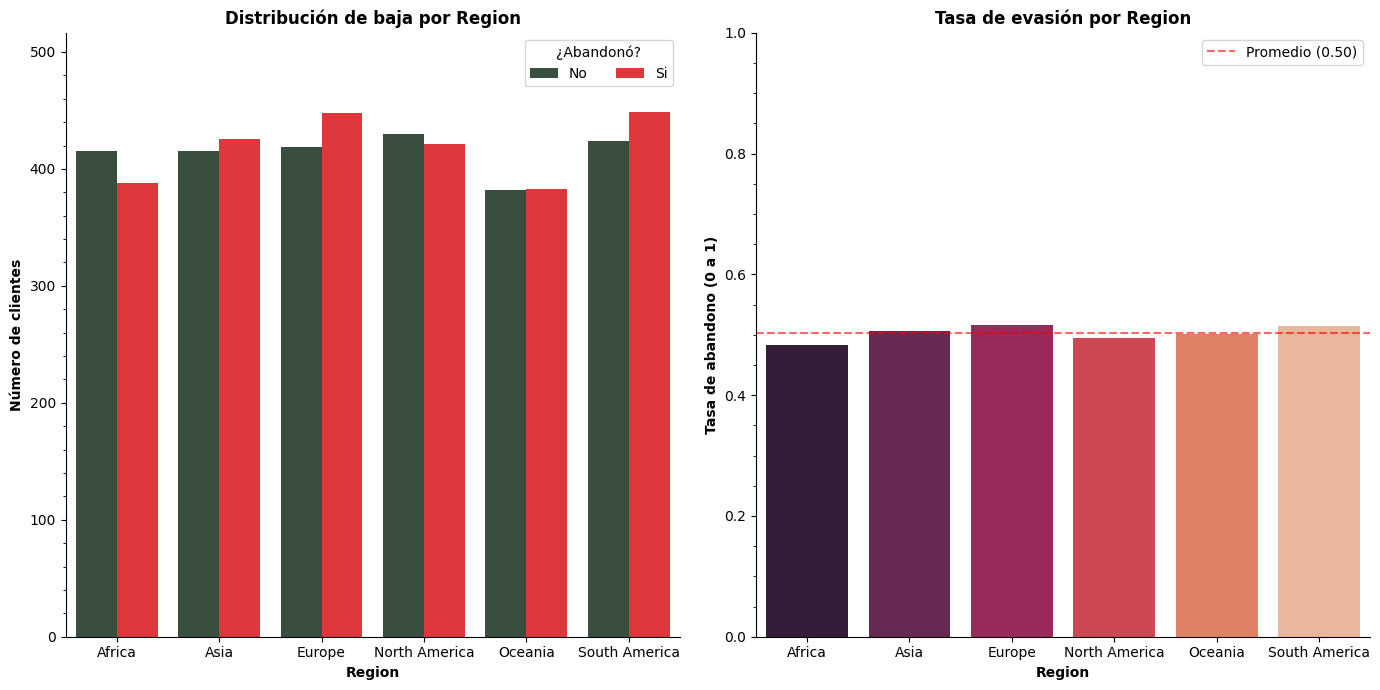

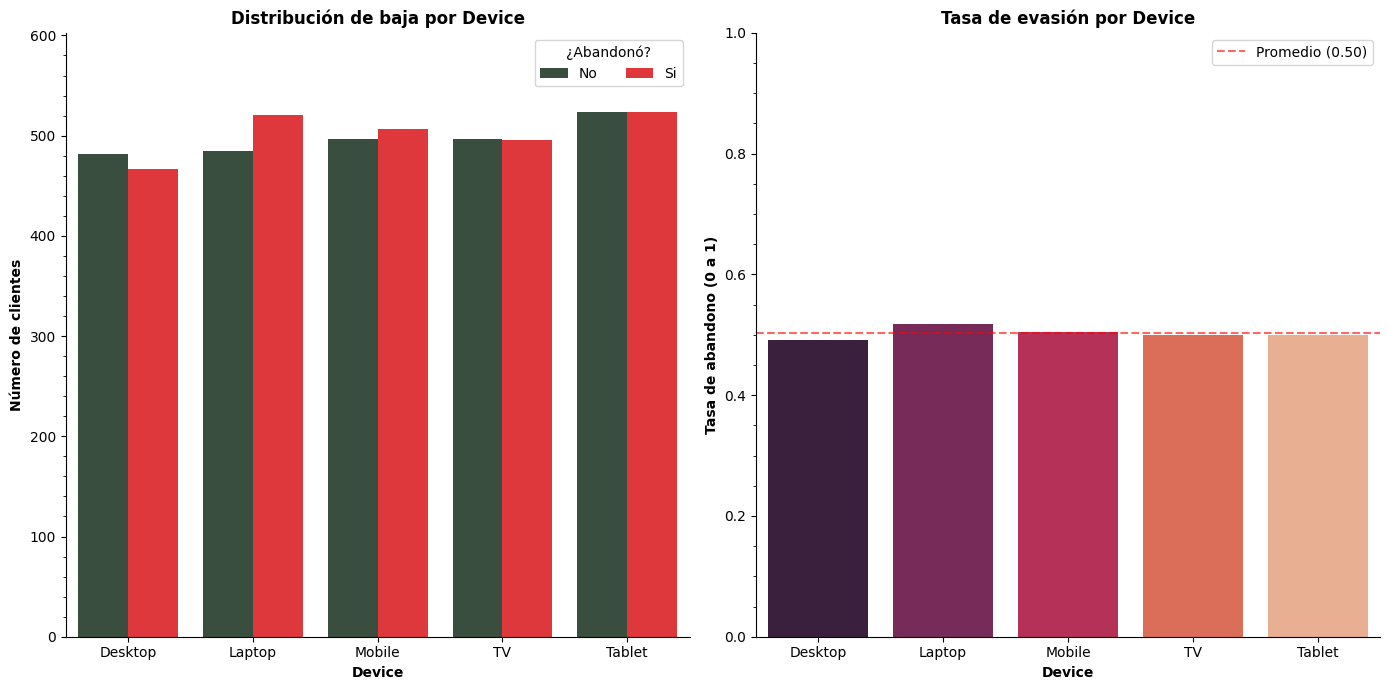

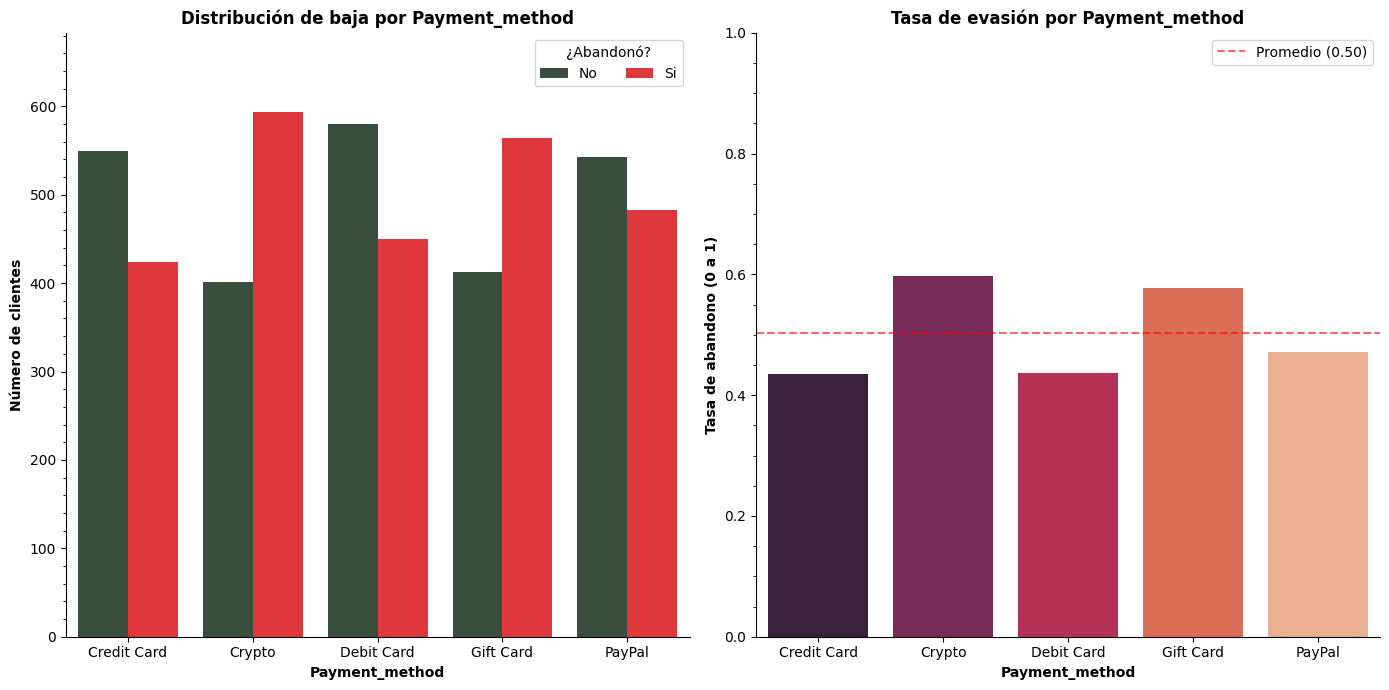

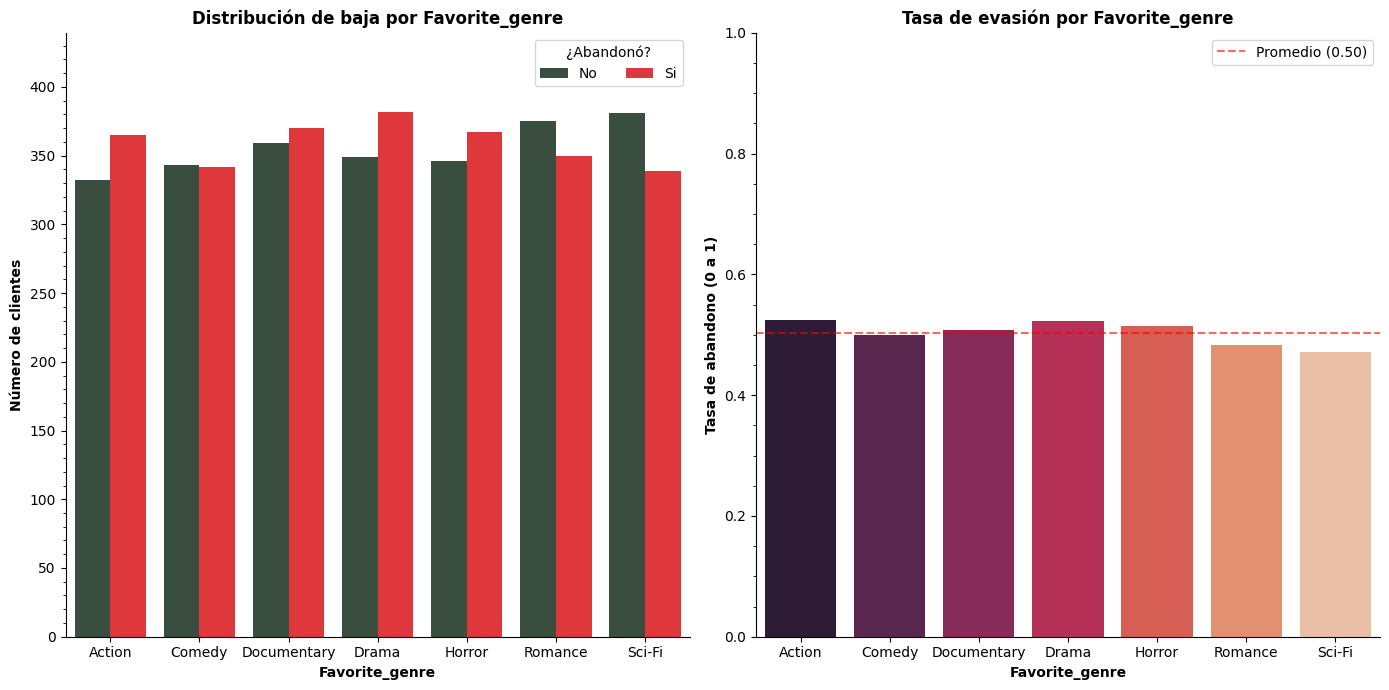

In [169]:
# Bucle que genera los gráficos de recuento de clientes que se dieron de baja
# y tasa de evasión de los clientes por categoría
for col in columnas_categoricas:
  tab_recuento = tabla_categorica(df, col, 'churned')
  tab_frecuencia = tabla_categorica(df, col, 'churned', normalize='index')

  graficos_categoricas(tab_recuento, tab_frecuencia, col)

##### Análisis de correlación

In [170]:
from scipy.stats import chi2_contingency

In [171]:
#Función que calcula el coeficiente v de cramer para analizar la correlación entre las variables categóricas
# y la variable cancelación
def calcular_v_cramer(conf_matrix):
    chi2 = chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = conf_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [172]:
#Bucle que calcula para cada columna categórica la correlación con la variable cancelación
for col in columnas_categoricas:
    tabla = pd.crosstab(df[col], df['churned'])
    chi2, p, dof, ex = chi2_contingency(tabla)
    v_cramer = calcular_v_cramer(tabla)

    print(f"Variable: {col}")
    print(f"P-valor: {p:.4f} ({'Significativo' if p < 0.05 else 'No significativo'})")
    print(f"V de Cramér: {v_cramer:.4f}")
    print("-" * 30)

Variable: gender
P-valor: 0.7225 (No significativo)
V de Cramér: 0.0000
------------------------------
Variable: subscription_type
P-valor: 0.0000 (Significativo)
V de Cramér: 0.1621
------------------------------
Variable: region
P-valor: 0.7531 (No significativo)
V de Cramér: 0.0000
------------------------------
Variable: device
P-valor: 0.8362 (No significativo)
V de Cramér: 0.0000
------------------------------
Variable: payment_method
P-valor: 0.0000 (Significativo)
V de Cramér: 0.1363
------------------------------
Variable: favorite_genre
P-valor: 0.3236 (No significativo)
V de Cramér: 0.0139
------------------------------


##### Averiguar si las variables subscripción y método de pago están relacionadas

In [173]:
#Tabla que contiene las frecuencias observadas de cada categoría
cruce = pd.crosstab(df['subscription_type'], df['payment_method'])

In [174]:
cruce

payment_method,Credit Card,Crypto,Debit Card,Gift Card,PayPal
subscription_type,,,,,
Basic,345,300,338,317,361
Premium,324,357,355,340,317
Standard,304,338,337,319,348


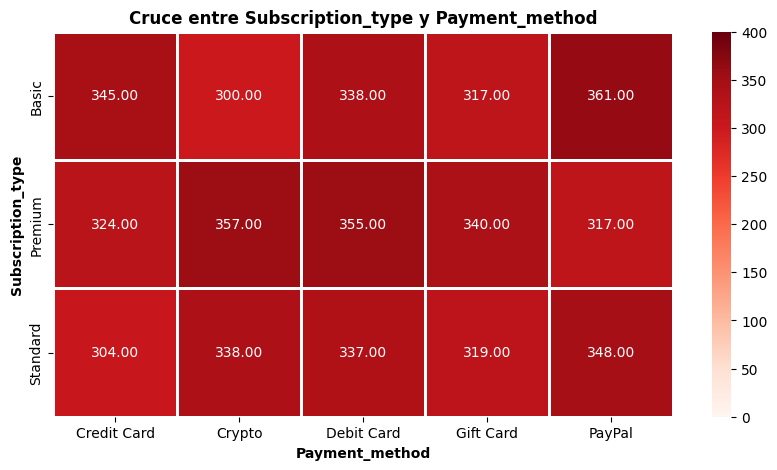

In [175]:
#Mapa de calor para observar las frecuencias por categoría
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.heatmap(cruce, vmin=0, vmax=400, annot=True, fmt=".2f", cmap='Reds', linewidths=.75)
ax.set_title(f'Cruce entre {cruce.index.name.capitalize()} y {cruce.columns.name.capitalize()}', fontsize=12, fontweight='bold')
ax.set_xlabel(f'{cruce.columns.name.capitalize()}', fontsize=10, fontweight='bold')
ax.set_ylabel(f'{cruce.index.name.capitalize()}', fontsize=10, fontweight='bold')

plt.show()

In [176]:
#Prueba de chi cuadrada entre las variables subscripción y método de pago
chi2, p, dof, ex = chi2_contingency(cruce)
print(f"Prueba de independencia entre {cruce.index.name} y {cruce.columns.name}")
print(f"Estadístico chi2: {chi2:.4f}, P-valor: {p:.4f} ({'Significativo' if p < 0.05 else 'No significativo'})")


Prueba de independencia entre subscription_type y payment_method
Estadístico chi2: 11.5316, P-valor: 0.1734 (No significativo)


### **Conclusión del análisis exploratorio**

Solo se trabajará el modelo con 7 variables adicionales a 'churned', que son las que impactan la predicción, estas son: 

- Subscription_type. 
- Payment_method". 
- Watch_hours
- Last_login_days
- Monthly_fee.
- Number_of_profiles.
- Avg_watch_time_per_day.

In [177]:
### **Guardar las columnas para el desarrollo del modelo predictivo**

In [178]:
df_model = df.drop(columns=['age', 'gender', 'region', 'device', 'payment_method', 'favorite_genre'], axis=1)

In [179]:
df_model.sample(5)

,subscription_type,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
4564,Standard,12.66,25,13.99,0,5,0.49
489,Premium,28.38,52,17.99,0,4,0.54
3505,Basic,11.24,37,8.99,1,4,0.30
4694,Premium,6.65,23,17.99,0,4,0.28
1391,Basic,8.48,39,8.99,1,5,0.21


In [180]:
# Guardar el DataFrame en un archivo CSV
df_model.to_csv('df_model.csv', index=False)